In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')

# Create high-resolution figures directory
FIGURES_DIR = Path('figures_final')
FIGURES_DIR.mkdir(exist_ok=True)

# =============================================================================
# PROFESSIONAL RESEARCH THEME - Publication-Quality Settings
# =============================================================================

# Use seaborn style with fallback for compatibility
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

# Override with publication-quality settings
plt.rcParams.update({
    # Font settings - serif for academic publications
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino', 'Georgia', 'serif'],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    
    # Figure settings
    'figure.figsize': (10, 6),
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'savefig.pad_inches': 0.1,
    
    # Axes settings - clean academic look
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    
    # Grid settings - subtle
    'grid.color': '#E5E5E5',
    'grid.linestyle': '-',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.7,
    
    # Legend settings
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.facecolor': 'white',
    'legend.edgecolor': '#CCCCCC',
    
    # Line and marker settings
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'patch.linewidth': 1.0,
    'patch.edgecolor': '#333333',
})

# =============================================================================
# PROFESSIONAL COLOR PALETTES
# =============================================================================

SOLVER_COLORS = {
    'greedy': '#2E7D32',      # Forest green
    'cost_norm': '#1565C0',   # Deep blue
    'dpp': '#6A1B9A',         # Deep purple
    'topk': '#C62828'         # Deep red
}

OBJECTIVE_COLORS = {
    'mmr': '#00695C',         # Teal
    'graphcut': '#E65100',    # Deep orange
    'fl': '#AD1457',          # Deep pink
    'dpp': '#4527A0'          # Deep purple
}

MODEL_COLORS = {
    'MiniLM-L6': '#D32F2F',
    'MPNet': '#1976D2',
    'BGE-M3': '#388E3C',
    'Stella-1.5B': '#7B1FA2',
    'Qwen-0.6B': '#F57C00',
    'Gemma-300M': '#00796B'
}

MODEL_MARKERS = {
    'MiniLM-L6': 'o',
    'MPNet': 's',
    'BGE-M3': '^',
    'Stella-1.5B': 'D',
    'Qwen-0.6B': 'v',
    'Gemma-300M': 'p'
}

PRIOR_COLORS = {
    'centroid': '#C62828',   # Deep red
    'coreset': '#1565C0'     # Deep blue
}

# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def save_figure(fig, filename, dpi=300, formats=['pdf', 'png']):
    """Save figure in multiple formats with consistent settings."""
    for fmt in formats:
        fig.savefig(FIGURES_DIR / f"{filename}.{fmt}", dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    
def get_color_palette(category):
    """Get appropriate color palette for category."""
    palettes = {
        'solver': SOLVER_COLORS,
        'objective': OBJECTIVE_COLORS,
        'model': MODEL_COLORS,
        'prior': PRIOR_COLORS
    }
    return palettes.get(category, {})

print(f"✓ Professional research theme applied")
print(f"✓ Figures directory: {FIGURES_DIR.absolute()}")

✓ Professional research theme applied
✓ Figures directory: /Users/vedumrajkar/Desktop/budgeted-ret/figures_final


In [2]:
def load_all_results(base_path: str = ".") -> pd.DataFrame:
    """
    Load all results from both Centroid and Coreset output directories.
    
    Returns:
        DataFrame with columns: budget, model, prior_method, strategy, objective, solver, config, + all metrics
    """
    base = Path(base_path)
    budgets = [250, 500, 750, 1000, 1250, 1500]
    all_records = []
    
    # Define directory patterns for both prior methods
    dir_patterns = [
        ('centroid', 'output{budget}'),
        ('coreset', 'output_coreset{budget}')
    ]
    
    for budget in budgets:
        for prior_method, dir_pattern in dir_patterns:
            output_dir = base / dir_pattern.format(budget=budget)
            
            if not output_dir.exists():
                continue
                
            for json_file in output_dir.glob("metrics_*.json"):
                try:
                    with open(json_file, 'r') as f:
                        data = json.load(f)
                    
                    model_name = data.get('model_name', 'unknown')
                    
                    for config_name, metrics in data.get('aggregate_metrics', {}).items():
                        parts = config_name.split('/')
                        record = {
                            'budget': budget,
                            'model': model_name,
                            'prior_method': prior_method,
                            'strategy': parts[0] if len(parts) > 0 else '',
                            'objective': parts[1] if len(parts) > 1 else '',
                            'solver': parts[2] if len(parts) > 2 else '',
                            'config': config_name,
                            **metrics
                        }
                        all_records.append(record)
                        
                except (json.JSONDecodeError, KeyError) as e:
                    print(f"Warning: Failed to load {json_file}: {e}")
                    continue
    
    if not all_records:
        raise ValueError("No valid results found. Check base_path and directory structure.")
    
    df = pd.DataFrame(all_records)
    
    # Summary statistics
    print(f"✓ Loaded {len(df):,} records across {df['model'].nunique()} models")
    print(f"  Prior methods: {df['prior_method'].unique().tolist()}")
    print(f"  Budgets: {sorted(df['budget'].unique().tolist())}")
    print(f"  Configurations: {df['config'].nunique()}")
    
    return df

# Load the data
df = load_all_results(base_path="output")
df.head()

✓ Loaded 720 records across 6 models
  Prior methods: ['centroid', 'coreset']
  Budgets: [250, 500, 750, 1000, 1250, 1500]
  Configurations: 10


,budget,model,prior_method,strategy,objective,solver,config,avg_decision_coverage,avg_density_phi,decision_D1_coverage,decision_D2_coverage,decision_D3_coverage,decision_D4_coverage,decision_D5_coverage,global_gr_coverage,redundancy_score,semantic_volume
0,250,BAAI/bge-m3,centroid,prior,mmr,greedy,prior/mmr/greedy,0.654181,0.031538,0.647608,0.660159,0.639049,0.629596,0.644452,0.629525,0.238111,-0.100795
1,250,BAAI/bge-m3,centroid,prior,graphcut,greedy,prior/graphcut/greedy,0.654276,0.031523,0.648258,0.660055,0.639019,0.629586,0.626361,0.629558,0.237834,-0.100337
2,250,BAAI/bge-m3,centroid,prior,fl,greedy,prior/fl/greedy,0.799150,0.017614,0.804056,0.795714,0.787266,0.767340,0.804616,0.784150,0.362935,-0.288208
3,250,BAAI/bge-m3,centroid,prior,mmr,cost_norm,prior/mmr/cost_norm,0.691785,0.026514,0.690694,0.688945,0.686325,0.670040,0.664431,0.673429,0.329098,-0.119842
4,250,BAAI/bge-m3,centroid,prior,graphcut,cost_norm,prior/graphcut/cost_norm,0.691785,0.026514,0.690694,0.688945,0.686325,0.670040,0.664431,0.673429,0.329098,-0.119842


In [3]:
# Save combined results
df.to_csv("all_results_combined.csv", index=False)
print(f"Saved combined results to all_results_combined.csv")

Saved combined results to all_results_combined.csv


In [4]:
# Preprocessing: Define display names and add short columns
METRIC_NAMES = {
    'global_gr_coverage': 'Global GR Coverage',
    'avg_decision_coverage': 'Avg. Decision Coverage',
    'redundancy_score': 'Redundancy',
    'avg_density_phi': 'Info. Density (φ)',
    'semantic_volume': 'Semantic Volume'
}

MODEL_SHORT_NAMES = {
    'all-MiniLM-L6-v2': 'MiniLM-L6',
    'all-mpnet-base-v2': 'MPNet',
    'BAAI/bge-m3': 'BGE-M3',
    'NovaSearch/stella_en_1.5B_v5': 'Stella-1.5B',
    'Qwen/Qwen3-Embedding-0.6B': 'Qwen-0.6B',
    'google/embeddinggemma-300m': 'Gemma-300M'
}

PRIOR_NAMES = {
    'centroid': 'Centroid',
    'coreset': 'Coreset (FL)'
}

# Add short names to dataframe
df['model_short'] = df['model'].map(lambda x: MODEL_SHORT_NAMES.get(x, x))
df['prior_display'] = df['prior_method'].map(lambda x: PRIOR_NAMES.get(x, x))

print("Preprocessing complete. Added model_short and prior_display columns.")

Preprocessing complete. Added model_short and prior_display columns.


In [5]:
print("="*80)
print("DATA SUMMARY")
print("="*80)
print(f"\nBudgets: {sorted(df['budget'].unique())}")
print(f"Prior Methods: {df['prior_method'].unique().tolist()}")
print(f"Models: {df['model_short'].unique().tolist()}")
print(f"Objectives: {df['objective'].unique().tolist()}")
print(f"Solvers: {df['solver'].unique().tolist()}")
print(f"\nRecords per prior method:")
print(df.groupby('prior_method').size())
print(f"\nTotal aggregate records: {len(df)}")
print(f"\nAll figures will be saved as high-resolution PDFs in: {FIGURES_DIR}")

DATA SUMMARY

Budgets: [250, 500, 750, 1000, 1250, 1500]
Prior Methods: ['centroid', 'coreset']
Models: ['BGE-M3', 'Stella-1.5B', 'MiniLM-L6', 'Gemma-300M', 'Qwen-0.6B', 'MPNet']
Objectives: ['mmr', 'graphcut', 'fl', 'dpp']
Solvers: ['greedy', 'cost_norm', 'dpp', 'topk']

Records per prior method:
prior_method
centroid    360
coreset     360
dtype: int64

Total aggregate records: 720

All figures will be saved as high-resolution PDFs in: figures_final


### Best perfomer by budget 

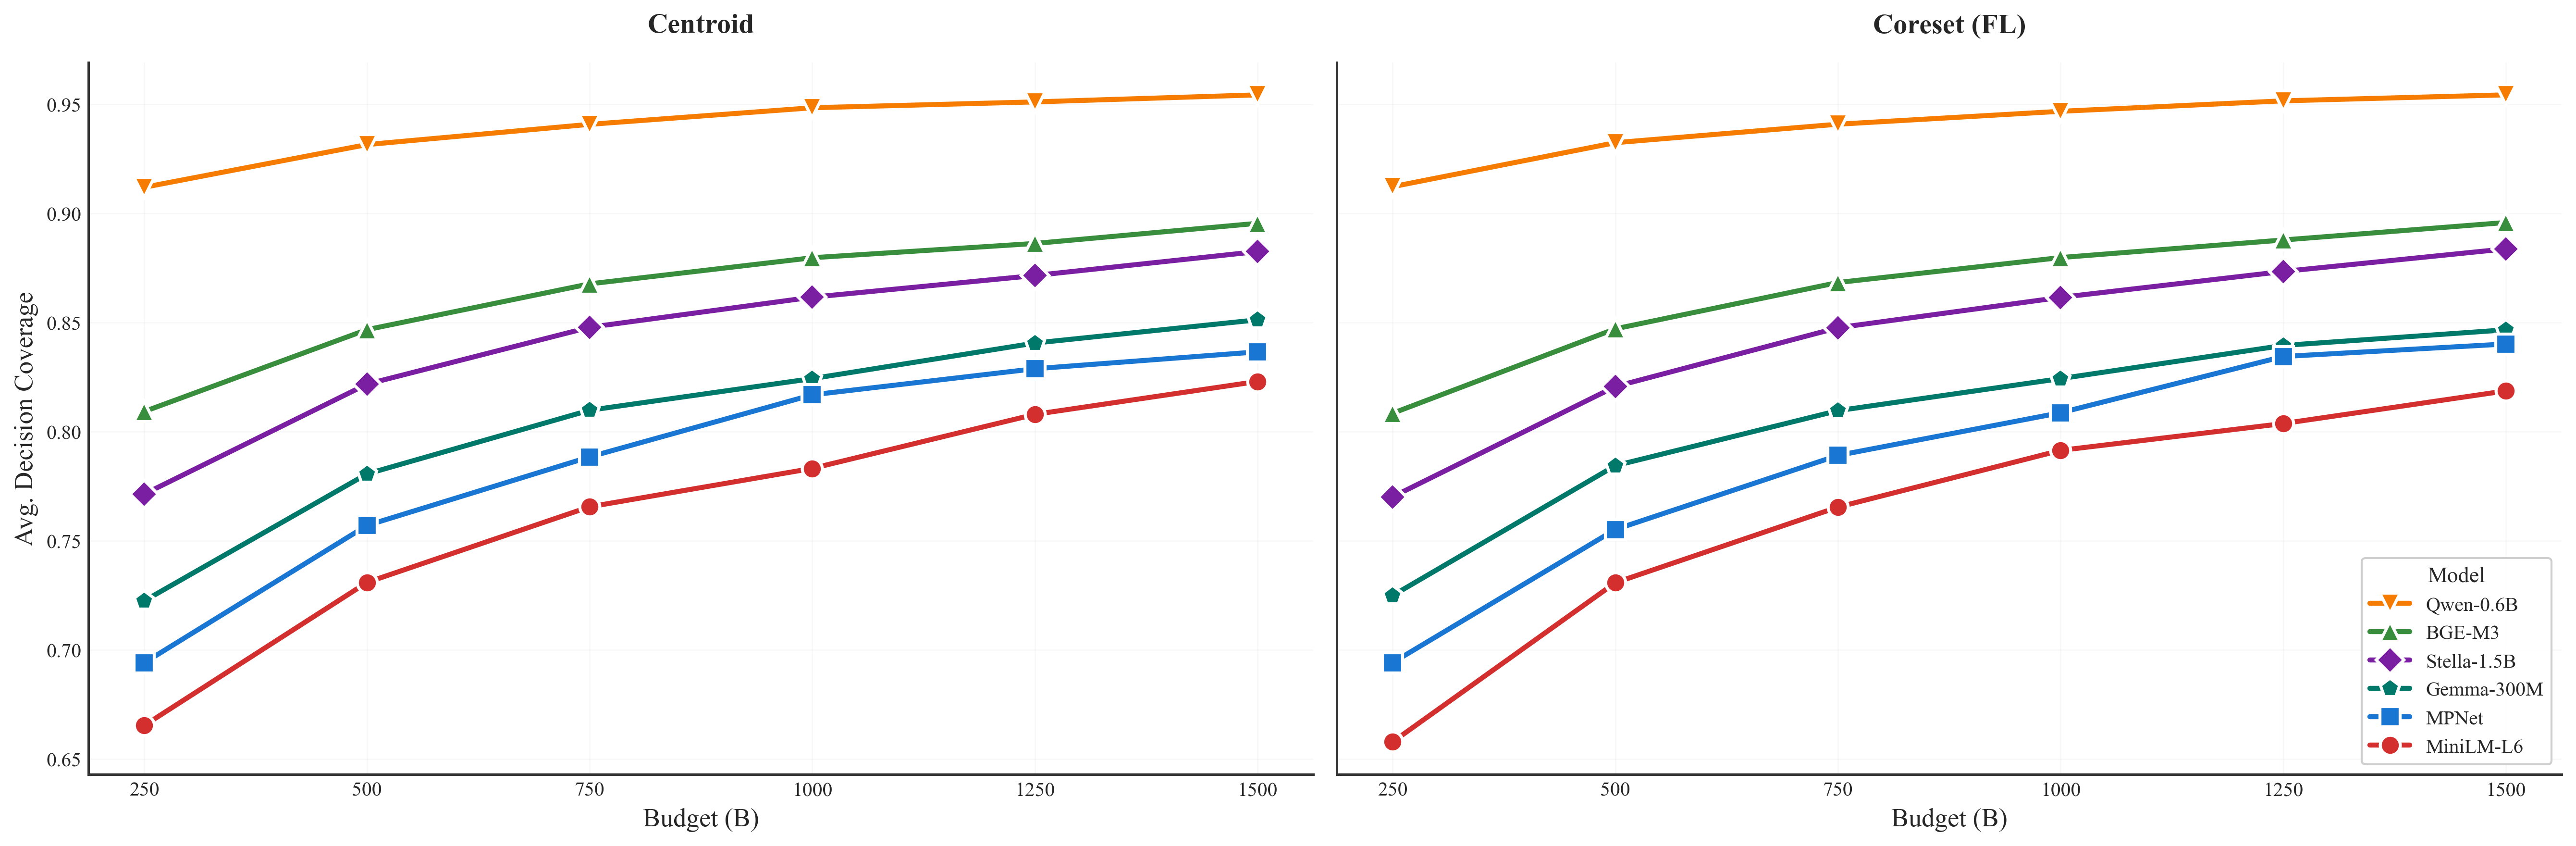


Best Model per Budget (Avg. Decision Coverage):

 Budget Centroid Best Centroid Score Coreset Best Coreset Score
    250     Qwen-0.6B         0.9120    Qwen-0.6B        0.9123
    500     Qwen-0.6B         0.9316    Qwen-0.6B        0.9324
    750     Qwen-0.6B         0.9408    Qwen-0.6B        0.9409
   1000     Qwen-0.6B         0.9484    Qwen-0.6B        0.9468
   1250     Qwen-0.6B         0.9511    Qwen-0.6B        0.9516
   1500     Qwen-0.6B         0.9543    Qwen-0.6B        0.9544


In [6]:
# ============================================================================
# PLOT 1: Model Performance Across Budgets (Line Plot)
# ============================================================================
def plot_model_performance_by_budget(df, metric, prior_method=None, figsize=(12, 7)):
    """Line plot showing each model's performance across budgets."""
    data = df if prior_method is None else df[df['prior_method'] == prior_method]
    
    # Get best config per model/budget
    grouped = data.groupby(['budget', 'model_short'])[metric].max().reset_index()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Sort models by their max performance (for legend ordering)
    model_max = grouped.groupby('model_short')[metric].max().sort_values(ascending=False)
    
    for model in model_max.index:
        model_data = grouped[grouped['model_short'] == model]
        color = MODEL_COLORS.get(model, '#333333')
        marker = MODEL_MARKERS.get(model, 'o')
        
        ax.plot(model_data['budget'], model_data[metric], '-', 
                marker=marker, label=model, color=color, 
                linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)
    
    ax.set_xlabel('Budget (B)', fontweight='medium')
    ax.set_ylabel(METRIC_NAMES.get(metric, metric), fontweight='medium')
    title = f'Model Comparison: {METRIC_NAMES.get(metric, metric)}'
    if prior_method:
        title += f' ({PRIOR_NAMES[prior_method]})'
    ax.set_title(title, pad=15)
    ax.legend(title='Model', loc='lower right', ncol=2, framealpha=0.95)
    ax.set_xticks(sorted(df['budget'].unique()))
    
    plt.tight_layout()
    return fig, ax

# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Centroid
data_cent = df[df['prior_method'] == 'centroid']
grouped_cent = data_cent.groupby(['budget', 'model_short'])['avg_decision_coverage'].max().reset_index()
model_max = grouped_cent.groupby('model_short')['avg_decision_coverage'].max().sort_values(ascending=False)
for model in model_max.index:
    model_data = grouped_cent[grouped_cent['model_short'] == model]
    ax1.plot(model_data['budget'], model_data['avg_decision_coverage'], '-', 
            marker=MODEL_MARKERS.get(model, 'o'), label=model, color=MODEL_COLORS.get(model, '#333333'),
            linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)
ax1.set_xlabel('Budget (B)', fontweight='medium')
ax1.set_ylabel('Avg. Decision Coverage', fontweight='medium')
ax1.set_title('Centroid', pad=15, fontweight='bold')
ax1.set_xticks(sorted(df['budget'].unique()))
ax1.grid(True, alpha=0.3)

# Coreset
data_core = df[df['prior_method'] == 'coreset']
grouped_core = data_core.groupby(['budget', 'model_short'])['avg_decision_coverage'].max().reset_index()
model_max = grouped_core.groupby('model_short')['avg_decision_coverage'].max().sort_values(ascending=False)
for model in model_max.index:
    model_data = grouped_core[grouped_core['model_short'] == model]
    ax2.plot(model_data['budget'], model_data['avg_decision_coverage'], '-',
            marker=MODEL_MARKERS.get(model, 'o'), label=model, color=MODEL_COLORS.get(model, '#333333'),
            linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)
ax2.set_xlabel('Budget (B)', fontweight='medium')
ax2.set_title('Coreset (FL)', pad=15, fontweight='bold')
ax2.set_xticks(sorted(df['budget'].unique()))
ax2.legend(title='Model', loc='lower right', ncol=1, framealpha=0.95)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_sidebyside.pdf')
plt.show()

# Generate table
print("\nBest Model per Budget (Avg. Decision Coverage):\n")
table_data = []
budgets = sorted(df['budget'].unique())
for budget in budgets:
    # Centroid best
    cent_best = df[(df['prior_method'] == 'centroid') & (df['budget'] == budget)].nlargest(1, 'avg_decision_coverage')
    # Coreset best  
    core_best = df[(df['prior_method'] == 'coreset') & (df['budget'] == budget)].nlargest(1, 'avg_decision_coverage')
    
    table_data.append({
        'Budget': budget,
        'Centroid Best': cent_best['model_short'].values[0],
        'Centroid Score': f"{cent_best['avg_decision_coverage'].values[0]:.4f}",
        'Coreset Best': core_best['model_short'].values[0],
        'Coreset Score': f"{core_best['avg_decision_coverage'].values[0]:.4f}"
    })

table_df = pd.DataFrame(table_data)
print(table_df.to_string(index=False))

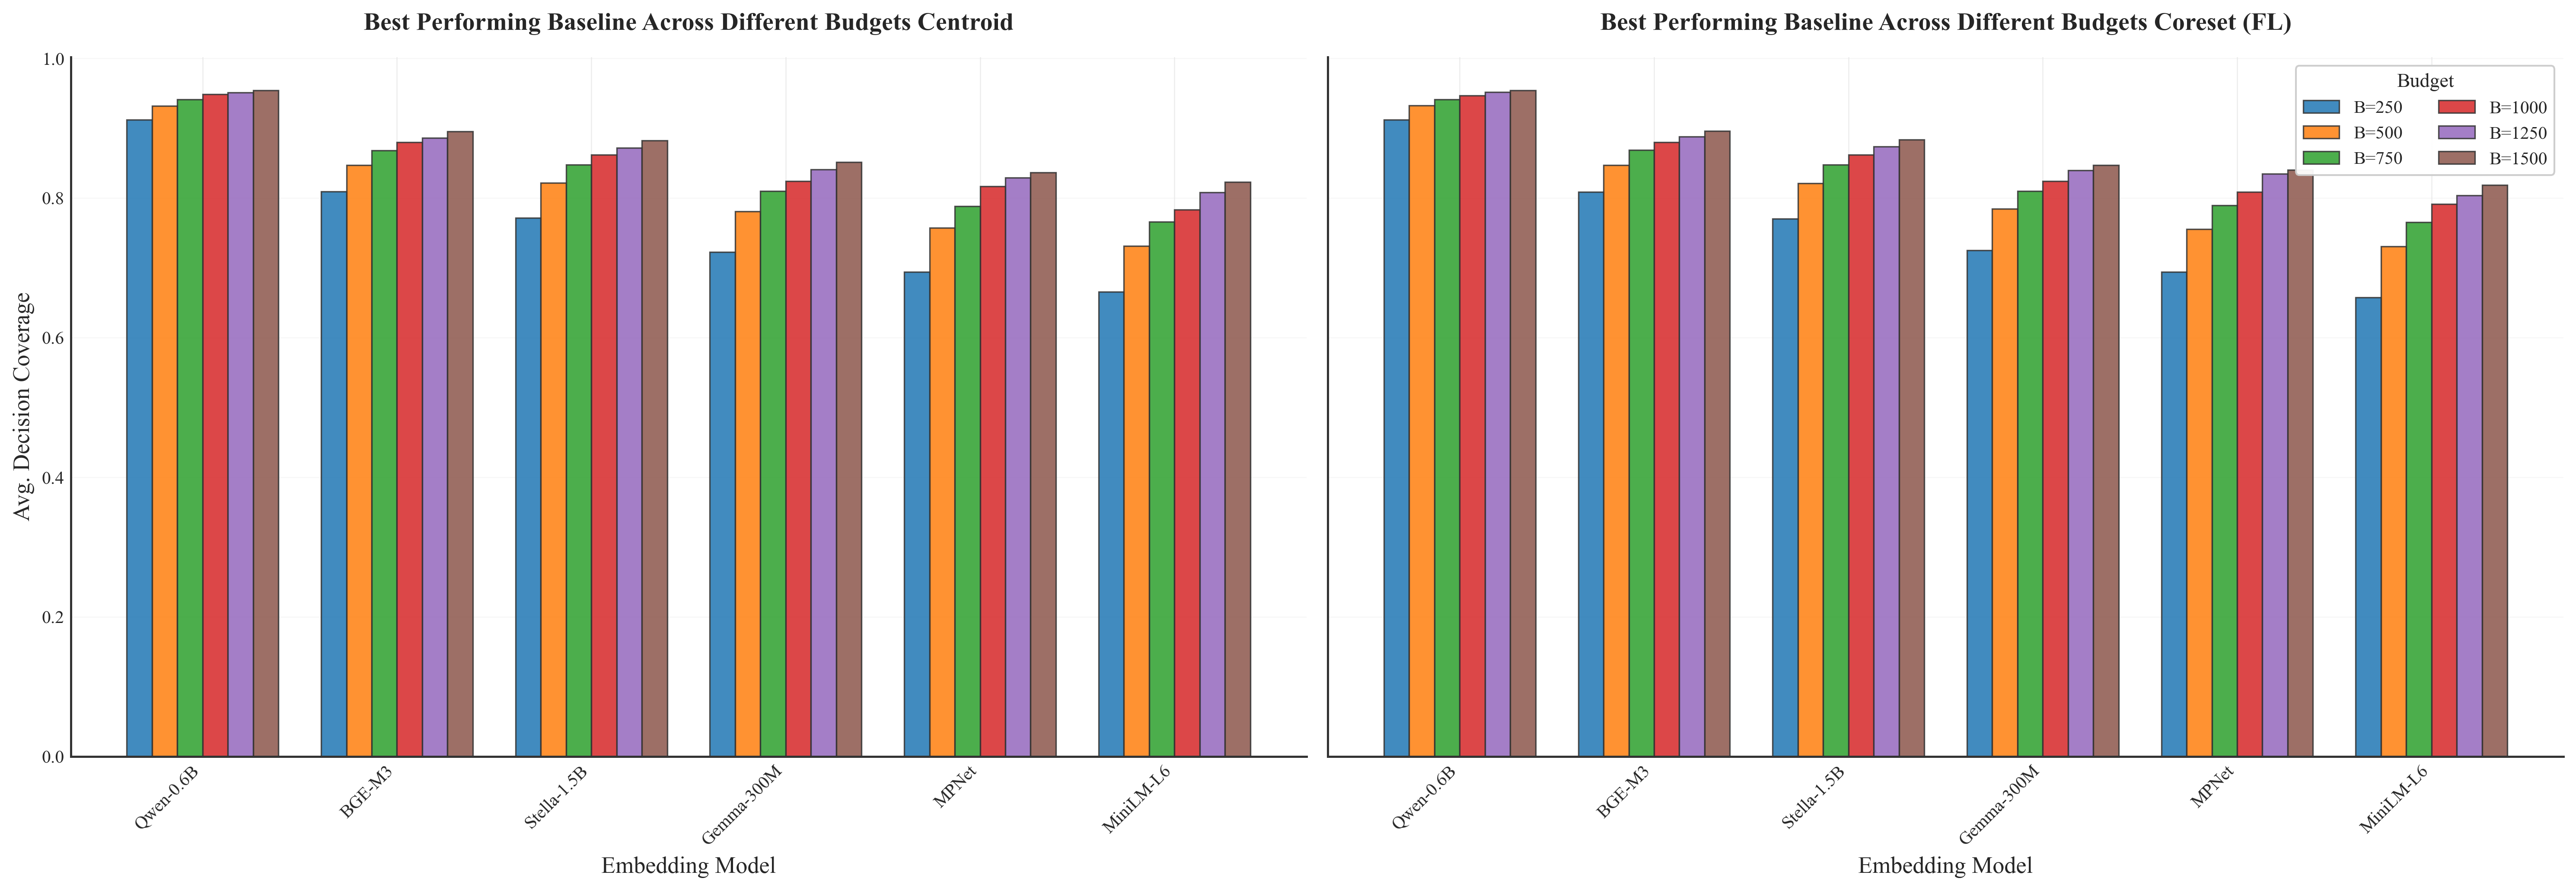

In [7]:
# ============================================================================
# PLOT 2: Model Performance Across Budgets - Grouped Bar Chart
# ============================================================================
def plot_model_performance_grouped_bars(df, metric, prior_method=None, figsize=(14, 7)):
    """Grouped bar chart showing all models across all budgets."""
    data = df if prior_method is None else df[df['prior_method'] == prior_method]
    
    # Get best config per model/budget
    grouped = data.groupby(['budget', 'model_short'])[metric].max().reset_index()
    pivot = grouped.pivot(index='model_short', columns='budget', values=metric)
    
    # Sort by average performance
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    budgets = sorted(df['budget'].unique())
    x = np.arange(len(pivot.index))
    width = 0.13  # Width of each bar
    
    # Plot bars for each budget
    for i, budget in enumerate(budgets):
        offset = (i - len(budgets)/2 + 0.5) * width
        bars = ax.bar(x + offset, pivot[budget], width, 
                     label=f'B={budget}',
                     alpha=0.85, edgecolor='#333333', linewidth=0.8)
        
        # Add value labels on top bars only (last budget)
        if i == len(budgets) - 1:
            for j, (bar, val) in enumerate(zip(bars, pivot[budget])):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='medium')
    
    ax.set_xlabel('Embedding Model', fontweight='medium')
    ax.set_ylabel(METRIC_NAMES.get(metric, metric), fontweight='medium')
    title = f'{METRIC_NAMES.get(metric, metric)} Across Budgets'
    if prior_method:
        title += f' ({PRIOR_NAMES[prior_method]})'
    ax.set_title(title, pad=15)
    
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontweight='medium')
    ax.legend(title='Budget', loc='upper right', ncol=2, framealpha=0.95)
    ax.set_ylim(pivot.values.min() - 0.03, pivot.values.max() + 0.04)
    
    plt.tight_layout()
    return fig, ax

# # Single comprehensive plot
# fig, ax = plot_model_performance_grouped_bars(df, 'avg_decision_coverage')
# plt.savefig(FIGURES_DIR / 'model_ranking_all_budgets_grouped.pdf')
# plt.show()

# Side-by-side for prior methods
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

for idx, (ax, prior) in enumerate([(ax1, 'centroid'), (ax2, 'coreset')]):
    data = df[df['prior_method'] == prior]
    grouped = data.groupby(['budget', 'model_short'])['avg_decision_coverage'].max().reset_index()
    pivot = grouped.pivot(index='model_short', columns='budget', values='avg_decision_coverage')
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    
    budgets = sorted(df['budget'].unique())
    x = np.arange(len(pivot.index))
    width = 0.13
    
    for i, budget in enumerate(budgets):
        offset = (i - len(budgets)/2 + 0.5) * width
        bars = ax.bar(x + offset, pivot[budget], width, 
                     label=f'B={budget}',
                     alpha=0.85, edgecolor='#333333', linewidth=0.8)
    
    ax.set_xlabel('Embedding Model', fontweight='medium')
    if idx == 0:
        ax.set_ylabel('Avg. Decision Coverage', fontweight='medium')
    ax.set_title("Best Performing Baseline Across Different Budgets " + PRIOR_NAMES[prior], pad=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontweight='medium')
    if idx == 1:
        ax.legend(title='Budget', loc='upper right', ncol=2, framealpha=0.95)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'best_baseline_model_ranking_budgets_sidebyside.pdf')
plt.show()



In [8]:
# # ============================================================================
# # PLOT 4: Model Performance by Solver - 1x4 Grid (All Side-by-Side)
# # ============================================================================
# def plot_model_by_solver_1x4(df, budget, figsize=(28, 7)):
#     """Grouped bar chart: 1x4 grid showing all combinations."""
    
#     fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=False)
    
#     prior_methods = ['centroid', 'coreset']
#     metrics = [
#         ('avg_decision_coverage', 'Avg. Decision Coverage'),
#         ('global_gr_coverage', 'Global GR Coverage')
#     ]
    
#     plot_idx = 0
#     for prior in prior_methods:
#         for metric, metric_label in metrics:
#             ax = axes[plot_idx]
            
#             data = df[(df['budget'] == budget) & (df['prior_method'] == prior)]
            
#             # Average across objectives for each model-solver pair
#             grouped = data.groupby(['model_short', 'solver'])[metric].mean().unstack()
            
#             # Sort models by mean performance (descending)
#             model_order = grouped.mean(axis=1).sort_values(ascending=False).index
#             grouped = grouped.loc[model_order]
            
#             x = np.arange(len(grouped.index))
#             width = 0.2
#             solvers = grouped.columns
            
#             for i, solver in enumerate(solvers):
#                 offset = (i - len(solvers)/2 + 0.5) * width
#                 bars = ax.bar(x + offset, grouped[solver], width, 
#                              label=solver.replace('_', ' ').title(),
#                              color=SOLVER_COLORS.get(solver, f'C{i}'),
#                              edgecolor='#333333', linewidth=0.8, zorder=3)
            
#             ax.set_xlabel('Embedding Model', fontweight='medium')
#             if plot_idx == 0:
#                 ax.set_ylabel(metric_label, fontweight='medium')
#             ax.set_xticks(x)
#             ax.set_xticklabels(grouped.index, rotation=45, ha='right', fontweight='medium')
#             ax.set_title(f'{PRIOR_NAMES[prior]} - {metric_label}', pad=15, fontweight='bold', fontsize=11)
#             ax.grid(True, alpha=0.3, axis='y')
            
#             # Legend only on last plot
#             if plot_idx == 3:
#                 ax.legend(title='Solver', loc='upper right', framealpha=0.95)
            
#             plot_idx += 1
    
#     fig.suptitle(f'Model Performance by Solver (B={budget})', 
#                  fontsize=16, fontweight='bold', y=1.00)
#     plt.tight_layout()
#     return fig, axes


# def generate_solver_comparison_table(df, metrics=['avg_decision_coverage', 'global_gr_coverage'], budget=1000, show_all_models=True):
#     """Generate comprehensive table across all models, solvers, and prior methods."""
    
#     print(f"\n{'='*160}")
#     print(f"COMPREHENSIVE SOLVER COMPARISON (Budget={budget})")
#     print(f"{'='*160}\n")
    
#     table_data = []
    
#     for prior in ['centroid', 'coreset']:
#         data = df[(df['budget'] == budget) & (df['prior_method'] == prior)]
        
#         if show_all_models:
#             # All models
#             grouped = data.groupby(['model_short', 'solver'])[metrics].mean().reset_index()
#             model_perf = grouped.groupby('model_short')[metrics[0]].mean().sort_values(ascending=False)
            
#             for model in model_perf.index:
#                 model_data = grouped[grouped['model_short'] == model]
                
#                 for _, row_data in model_data.iterrows():
#                     row = {
#                         'Prior': PRIOR_NAMES[prior],
#                         'Model': model,
#                         'Solver': row_data['solver'].replace('_', ' ').title(),
#                     }
#                     for metric in metrics:
#                         row[METRIC_NAMES.get(metric, metric)] = f"{row_data[metric]:.4f}"
#                     table_data.append(row)
#         else:
#             # Best model only
#             best_model = data.groupby('model_short')[metrics[0]].mean().idxmax()
#             model_data = data[data['model_short'] == best_model]
#             grouped = model_data.groupby('solver')[metrics].mean().reset_index()
            
#             for _, row_data in grouped.iterrows():
#                 row = {
#                     'Prior': PRIOR_NAMES[prior],
#                     'Model': best_model,
#                     'Solver': row_data['solver'].replace('_', ' ').title(),
#                 }
#                 for metric in metrics:
#                     row[METRIC_NAMES.get(metric, metric)] = f"{row_data[metric]:.4f}"
#                 table_data.append(row)
    
#     table_df = pd.DataFrame(table_data)
#     print(table_df.to_string(index=False))
#     print(f"\n{'='*160}\n")
    
#     return table_df


# # Generate 1x4 plot for B=1000
# print(f"\n{'#'*100}")
# print(f"BUDGET = 1000")
# print(f"{'#'*100}")

# fig, axes = plot_model_by_solver_1x4(df, budget=1000)
# plt.savefig(FIGURES_DIR / f'model_by_solver_1x4_B1000.pdf')
# plt.show()

# # Generate comprehensive table
# solver_table = generate_solver_comparison_table(df, metrics=['avg_decision_coverage', 'global_gr_coverage'], 
#                                                budget=1000, show_all_models=True)

# print(f"\n✓ Saved solver comparison 1x4 plot to {FIGURES_DIR}")

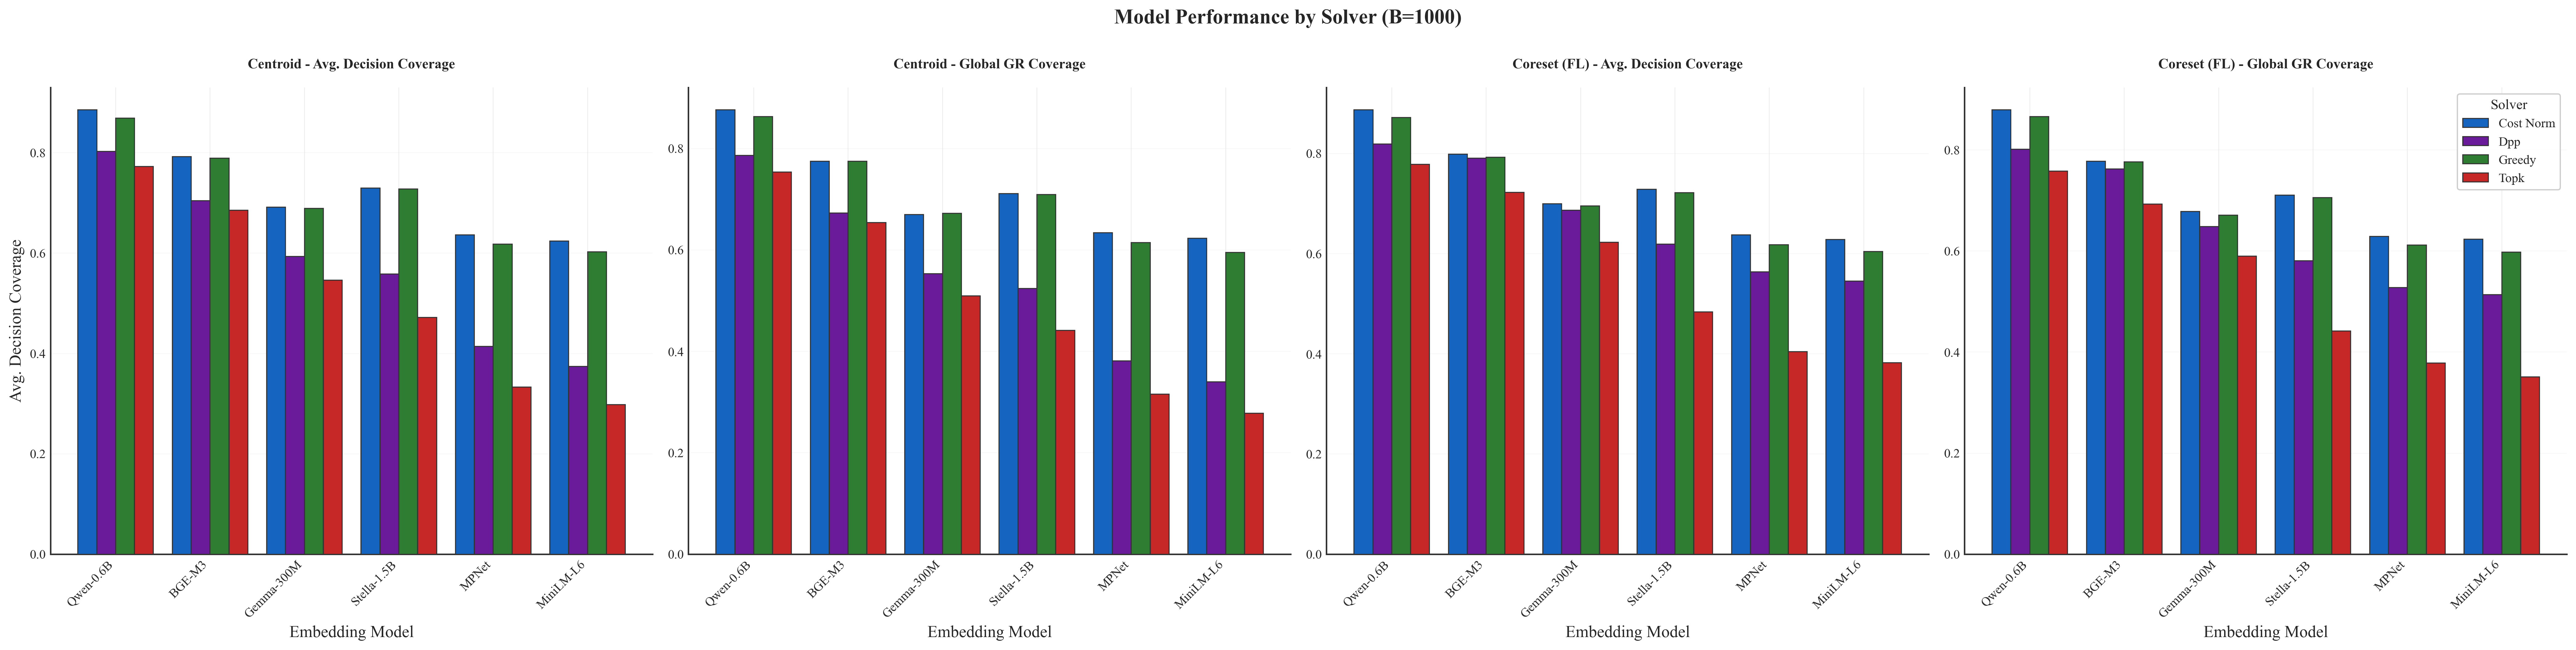


✓ Saved model by solver 1x4 plot to figures_final


In [9]:
# ============================================================================
# PLOT 4: Model Performance by Solver - 1x4 Grid (All Side-by-Side)
# ============================================================================
def plot_model_by_solver_1x4(df, budget, figsize=(28, 7)):
    """Grouped bar chart: 1x4 grid showing all combinations."""
    
    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=False)
    
    prior_methods = ['centroid', 'coreset']
    metrics = [
        ('avg_decision_coverage', 'Avg. Decision Coverage'),
        ('global_gr_coverage', 'Global GR Coverage')
    ]
    
    plot_idx = 0
    for prior in prior_methods:
        for metric, metric_label in metrics:
            ax = axes[plot_idx]
            
            data = df[(df['budget'] == budget) & (df['prior_method'] == prior)]
            
            # Average across objectives for each model-solver pair
            grouped = data.groupby(['model_short', 'solver'])[metric].mean().unstack()
            
            # Sort models by mean performance (descending)
            model_order = grouped.mean(axis=1).sort_values(ascending=False).index
            grouped = grouped.loc[model_order]
            
            x = np.arange(len(grouped.index))
            width = 0.2
            solvers = grouped.columns
            
            for i, solver in enumerate(solvers):
                offset = (i - len(solvers)/2 + 0.5) * width
                bars = ax.bar(x + offset, grouped[solver], width, 
                             label=solver.replace('_', ' ').title(),
                             color=SOLVER_COLORS.get(solver, f'C{i}'),
                             edgecolor='#333333', linewidth=0.8, zorder=3)
            
            ax.set_xlabel('Embedding Model', fontweight='medium')
            if plot_idx == 0:
                ax.set_ylabel(metric_label, fontweight='medium')
            ax.set_xticks(x)
            ax.set_xticklabels(grouped.index, rotation=45, ha='right', fontweight='medium')
            ax.set_title(f'{PRIOR_NAMES[prior]} - {metric_label}', pad=15, fontweight='bold', fontsize=11)
            ax.grid(True, alpha=0.3, axis='y')
            
            # Legend only on last plot
            if plot_idx == 3:
                ax.legend(title='Solver', loc='upper right', framealpha=0.95)
            
            plot_idx += 1
    
    fig.suptitle(f'Model Performance by Solver (B={budget})', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    return fig, axes

# Generate 1x4 plot for B=1000
fig, axes = plot_model_by_solver_1x4(df, budget=1000)
plt.savefig(FIGURES_DIR / f'model_by_solver_1x4_B1000.pdf')
plt.show()

print(f"\n✓ Saved model by solver 1x4 plot to {FIGURES_DIR}")

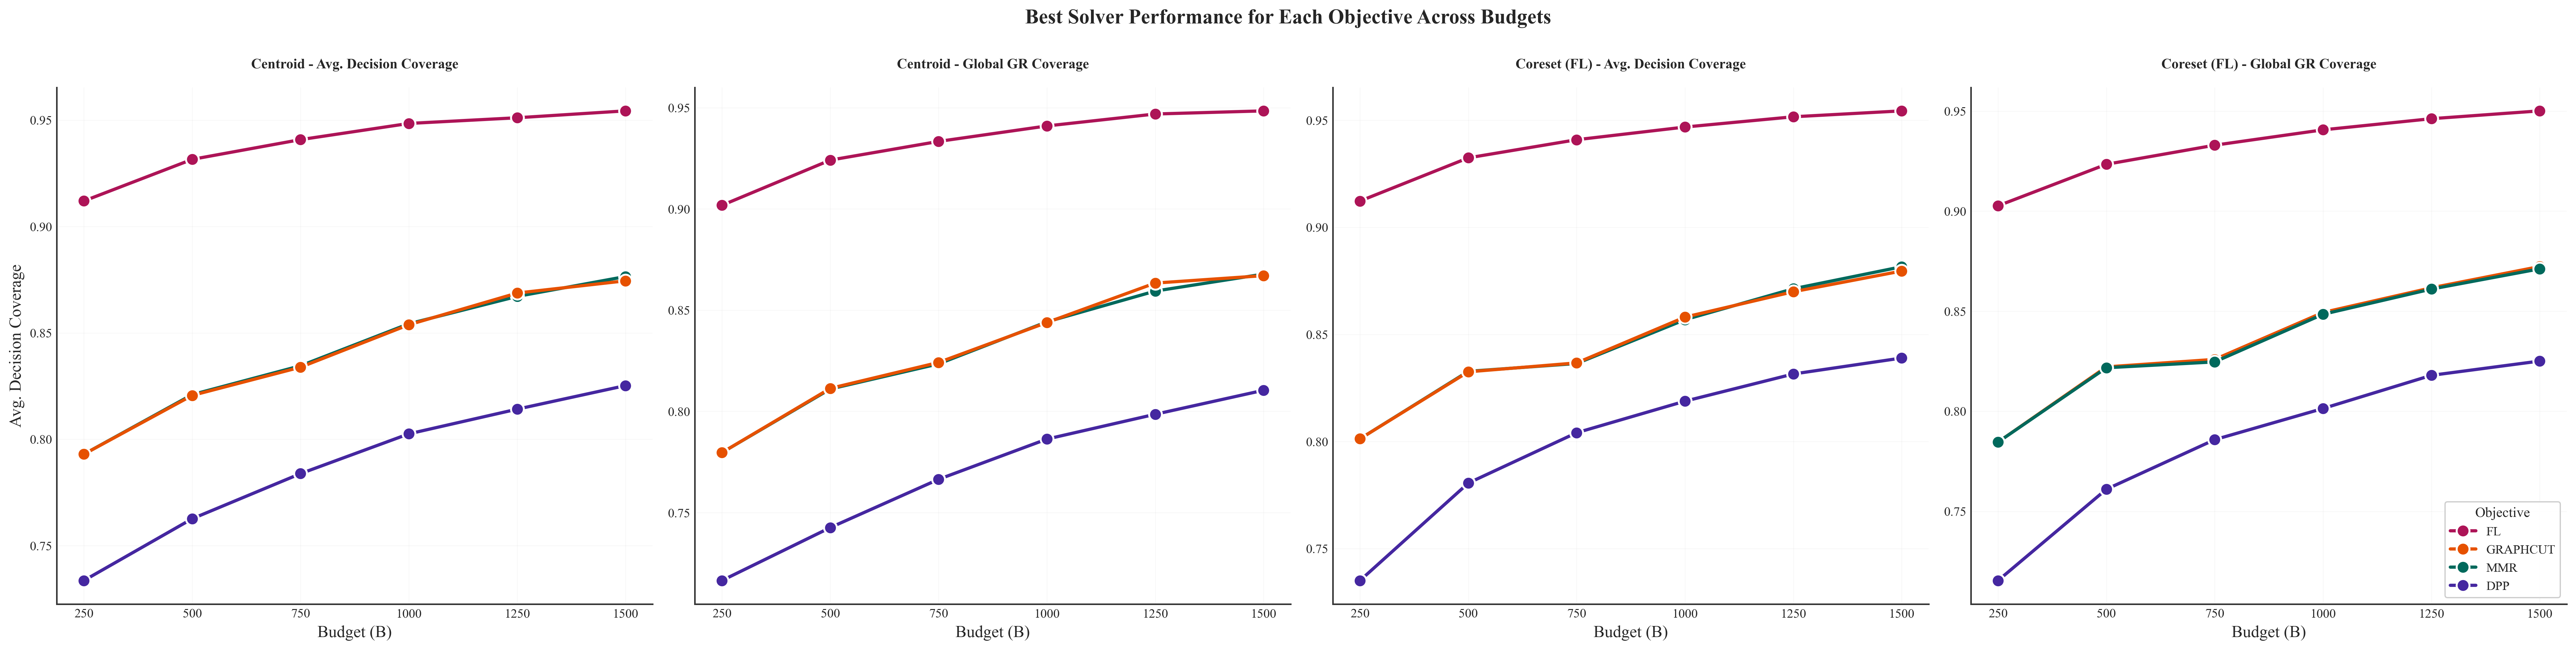


✓ Saved budget scaling by objective 1x4 plot to figures_final


In [10]:
# ============================================================================
# PLOT 9: Budget Scaling by Objective - 1x4 Grid (Best Performance)
# ============================================================================
def plot_budget_scaling_by_objective_1x4(df, figsize=(28, 7)):
    """Line plot: 1x4 grid showing best objective performance across budgets."""
    
    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=False)
    
    prior_methods = ['centroid', 'coreset']
    metrics = [
        ('avg_decision_coverage', 'Avg. Decision Coverage'),
        ('global_gr_coverage', 'Global GR Coverage')
    ]
    
    plot_idx = 0
    for prior in prior_methods:
        for metric, metric_label in metrics:
            ax = axes[plot_idx]
            
            data = df[df['prior_method'] == prior]
            
            # Take max across models and solvers for each budget-objective combination
            grouped = data.groupby(['budget', 'objective'])[metric].max().reset_index()
            
            # Sort objectives by max performance
            obj_max = grouped.groupby('objective')[metric].max().sort_values(ascending=False)
            
            for obj in obj_max.index:
                obj_data = grouped[grouped['objective'] == obj]
                color = OBJECTIVE_COLORS.get(obj, '#333333')
                
                ax.plot(obj_data['budget'], obj_data[metric], '-o',
                        label=obj.upper(), color=color, linewidth=2.5, markersize=10,
                        markeredgecolor='white', markeredgewidth=1.5)
            
            ax.set_xlabel('Budget (B)', fontweight='medium')
            if plot_idx == 0:
                ax.set_ylabel(metric_label, fontweight='medium')
            ax.set_title(f'{PRIOR_NAMES[prior]} - {metric_label}', pad=15, fontweight='bold', fontsize=11)
            ax.set_xticks(sorted(df['budget'].unique()))
            ax.grid(True, alpha=0.3)
            
            # Legend only on last plot
            if plot_idx == 3:
                ax.legend(title='Objective', loc='lower right', framealpha=0.95)
            
            plot_idx += 1
    
    fig.suptitle('Best Solver Performance for Each Objective Across Budgets', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    return fig, axes

# Generate 1x4 plot
fig, axes = plot_budget_scaling_by_objective_1x4(df)
plt.savefig(FIGURES_DIR / 'budget_scaling_objective_1x4_best.pdf')
plt.show()

print(f"\n✓ Saved budget scaling by objective 1x4 plot to {FIGURES_DIR}")

In [11]:
def generate_comprehensive_solver_table(df, metrics=['avg_decision_coverage', 'global_gr_coverage'], budget=None, show_all_models=True):
    """
    Generate comprehensive table of solver performance across models, objectives, and prior methods.
    
    Args:
        df: DataFrame with results
        metrics: List of metrics to analyze (will appear as separate columns)
        budget: If specified, show only this budget. If None, show all budgets.
        show_all_models: If True, show all models. If False, show only best model per budget/prior.
    """
    
    print(f"\n{'='*160}")
    title = f"COMPREHENSIVE SOLVER COMPARISON"
    if budget:
        title += f" (Budget={budget})"
    print(title)
    print(f"{'='*160}\n")
    
    table_data = []
    budgets = [budget] if budget else sorted(df['budget'].unique())
    
    for prior in ['centroid', 'coreset']:
        for b in budgets:
            data = df[(df['budget'] == b) & (df['prior_method'] == prior)]
            
            if show_all_models:
                # Group by model, objective, solver - keep all combinations
                grouped = data.groupby(['model_short', 'objective', 'solver'])[metrics].mean().reset_index()
                
                # Sort by model performance on first metric
                model_perf = grouped.groupby('model_short')[metrics[0]].mean().sort_values(ascending=False)
                
                for model in model_perf.index:
                    model_data = grouped[grouped['model_short'] == model]
                    
                    for _, row_data in model_data.iterrows():
                        row = {
                            'Prior': PRIOR_NAMES[prior],
                            'Budget': b,
                            'Model': model,
                            'Objective': row_data['objective'].upper(),
                            'Solver': row_data['solver'].replace('_', ' ').title(),
                        }
                        # Add each metric as a column
                        for metric in metrics:
                            row[METRIC_NAMES.get(metric, metric)] = f"{row_data[metric]:.4f}"
                        table_data.append(row)
            else:
                # Best model only
                best_model = data.groupby('model_short')[metrics[0]].mean().idxmax()
                model_data = data[data['model_short'] == best_model]
                grouped = model_data.groupby(['objective', 'solver'])[metrics].mean().reset_index()
                
                for _, row_data in grouped.iterrows():
                    row = {
                        'Prior': PRIOR_NAMES[prior],
                        'Budget': b,
                        'Model': best_model,
                        'Objective': row_data['objective'].upper(),
                        'Solver': row_data['solver'].replace('_', ' ').title(),
                    }
                    # Add each metric as a column
                    for metric in metrics:
                        row[METRIC_NAMES.get(metric, metric)] = f"{row_data[metric]:.4f}"
                    table_data.append(row)
    
    table_df = pd.DataFrame(table_data)
    print(table_df.to_string(index=False))
    print(f"\n{'='*160}\n")
    
    return table_df

# Example usage - all models at B=1000 with both metrics
table_1000_all = generate_comprehensive_solver_table(df, 
                                                      metrics=['avg_decision_coverage', 'global_gr_coverage'], 
                                                      budget=1000, 
                                                      show_all_models=True)

# Example usage - best models across all budgets with both metrics
# table_best_all = generate_comprehensive_solver_table(df, 
#                                                       metrics=['avg_decision_coverage', 'global_gr_coverage'],
#                                                       budget=None, 
#                                                       show_all_models=False)


COMPREHENSIVE SOLVER COMPARISON (Budget=1000)

       Prior  Budget       Model Objective    Solver Avg. Decision Coverage Global GR Coverage
    Centroid    1000   Qwen-0.6B       DPP       Dpp                 0.8025             0.7863
    Centroid    1000   Qwen-0.6B        FL Cost Norm                 0.9484             0.9410
    Centroid    1000   Qwen-0.6B        FL    Greedy                 0.9419             0.9316
    Centroid    1000   Qwen-0.6B        FL      Topk                 0.7728             0.7537
    Centroid    1000   Qwen-0.6B  GRAPHCUT Cost Norm                 0.8538             0.8439
    Centroid    1000   Qwen-0.6B  GRAPHCUT    Greedy                 0.8278             0.8256
    Centroid    1000   Qwen-0.6B  GRAPHCUT      Topk                 0.7728             0.7537
    Centroid    1000   Qwen-0.6B       MMR Cost Norm                 0.8543             0.8442
    Centroid    1000   Qwen-0.6B       MMR    Greedy                 0.8365             0.8317
  

## corpus filtering

In [12]:
# ============================================================================
# Load filter experiment results
# ============================================================================
df_filter = pd.read_csv("filter_experiment_results.csv")

# Add short model names
df_filter['model_short'] = df_filter['model'].map(lambda x: MODEL_SHORT_NAMES.get(x, x))
df_filter['prior_display'] = df_filter['prior_method'].map(lambda x: PRIOR_NAMES.get(x, x))
df_filter['prior_method'] = df_filter['prior_method'].replace('kmeans', 'centroid')


print(f"Filter experiment records: {len(df_filter)}")
print(f"Models: {df_filter['model_short'].unique().tolist()}")
print(f"Prior methods: {df_filter['prior_method'].unique().tolist()}")
print(f"Retention levels: {sorted(df_filter['retain_pct'].unique().tolist())}")
print(f"Papers per model: {df_filter.groupby('model_short')['paper_id'].nunique().to_dict()}")
df_filter.head(10)

Filter experiment records: 15264
Models: ['Gemma-300M', 'MiniLM-L6', 'MPNet', 'BGE-M3', 'Stella-1.5B', 'Qwen-0.6B']
Prior methods: ['centroid', 'coreset']
Retention levels: [0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
Papers per model: {'BGE-M3': 212, 'Gemma-300M': 212, 'MPNet': 212, 'MiniLM-L6': 212, 'Qwen-0.6B': 212, 'Stella-1.5B': 212}


,model,prior_method,paper_id,retain_pct,retain_pct_display,num_units,gr_coverage,avg_dec_coverage,oracle_retention,selected_count,model_short,prior_display
0,google/embeddinggemma-300m,centroid,1023_slides.pdf,1.00,100%,153,0.697458,0.603813,1.000000,8,Gemma-300M,kmeans
1,google/embeddinggemma-300m,centroid,1023_slides.pdf,0.03,3%,4,0.334309,0.453666,0.125000,4,Gemma-300M,kmeans
2,google/embeddinggemma-300m,centroid,1023_slides.pdf,0.05,5%,7,0.402616,0.496567,0.125000,6,Gemma-300M,kmeans
3,google/embeddinggemma-300m,centroid,1023_slides.pdf,0.10,10%,15,0.400645,0.528323,0.250000,6,Gemma-300M,kmeans
4,google/embeddinggemma-300m,centroid,1023_slides.pdf,0.20,20%,30,0.552883,0.646170,0.500000,7,Gemma-300M,kmeans
5,google/embeddinggemma-300m,centroid,1023_slides.pdf,0.50,50%,76,0.713232,0.592373,0.875000,6,Gemma-300M,kmeans
6,google/embeddinggemma-300m,centroid,1017_slides.pdf,1.00,100%,192,0.701555,0.589063,1.000000,7,Gemma-300M,kmeans
7,google/embeddinggemma-300m,centroid,1017_slides.pdf,0.03,3%,5,0.587186,0.527156,0.142857,4,Gemma-300M,kmeans
8,google/embeddinggemma-300m,centroid,1017_slides.pdf,0.05,5%,9,0.704569,0.583273,0.142857,5,Gemma-300M,kmeans
9,google/embeddinggemma-300m,centroid,1017_slides.pdf,0.10,10%,19,0.727991,0.643661,0.142857,6,Gemma-300M,kmeans


In [13]:
# ============================================================================
# Aggregate filter results
# ============================================================================
df_filter_agg = df_filter.groupby(['model', 'model_short', 'prior_method', 'prior_display', 'retain_pct']).agg(
    gr_coverage=('gr_coverage', 'mean'),
    avg_dec_coverage=('avg_dec_coverage', 'mean'),
    oracle_retention=('oracle_retention', 'mean'),
    num_units=('num_units', 'mean'),
    selected_count=('selected_count', 'mean'),
    num_papers=('paper_id', 'nunique'),
).reset_index()

df_filter_agg['retain_pct_display'] = (df_filter_agg['retain_pct'] * 100).astype(int).astype(str) + '%'

print(f"✓ Aggregated filter records: {len(df_filter_agg)}")
print(f"✓ Prior methods: {df_filter_agg['prior_method'].unique().tolist()}")
df_filter_agg.head(15)

✓ Aggregated filter records: 72
✓ Prior methods: ['centroid', 'coreset']


,model,model_short,prior_method,prior_display,retain_pct,gr_coverage,avg_dec_coverage,oracle_retention,num_units,selected_count,num_papers,retain_pct_display
0,BAAI/bge-m3,BGE-M3,centroid,kmeans,0.03,0.604037,0.635190,0.193359,4.877358,4.113208,212,3%
1,BAAI/bge-m3,BGE-M3,centroid,kmeans,0.05,0.640254,0.670890,0.216747,8.518868,4.966981,212,5%
2,BAAI/bge-m3,BGE-M3,centroid,kmeans,0.10,0.681740,0.714542,0.298093,17.603774,5.386792,212,10%
3,BAAI/bge-m3,BGE-M3,centroid,kmeans,0.20,0.714520,0.745309,0.415512,35.669811,5.660377,212,20%
4,BAAI/bge-m3,BGE-M3,centroid,kmeans,0.50,0.739897,0.757634,0.698555,89.849057,5.721698,212,50%
5,BAAI/bge-m3,BGE-M3,centroid,kmeans,1.00,0.739301,0.753108,1.000000,180.198113,5.750000,212,100%
6,BAAI/bge-m3,BGE-M3,coreset,Coreset (FL),0.03,0.653466,0.683668,0.211480,4.877358,4.113208,212,3%
7,BAAI/bge-m3,BGE-M3,coreset,Coreset (FL),0.05,0.700628,0.732740,0.237069,8.518868,5.056604,212,5%
8,BAAI/bge-m3,BGE-M3,coreset,Coreset (FL),0.10,0.754715,0.781493,0.277278,17.603774,5.537736,212,10%
9,BAAI/bge-m3,BGE-M3,coreset,Coreset (FL),0.20,0.760475,0.786227,0.398100,35.669811,5.655660,212,20%


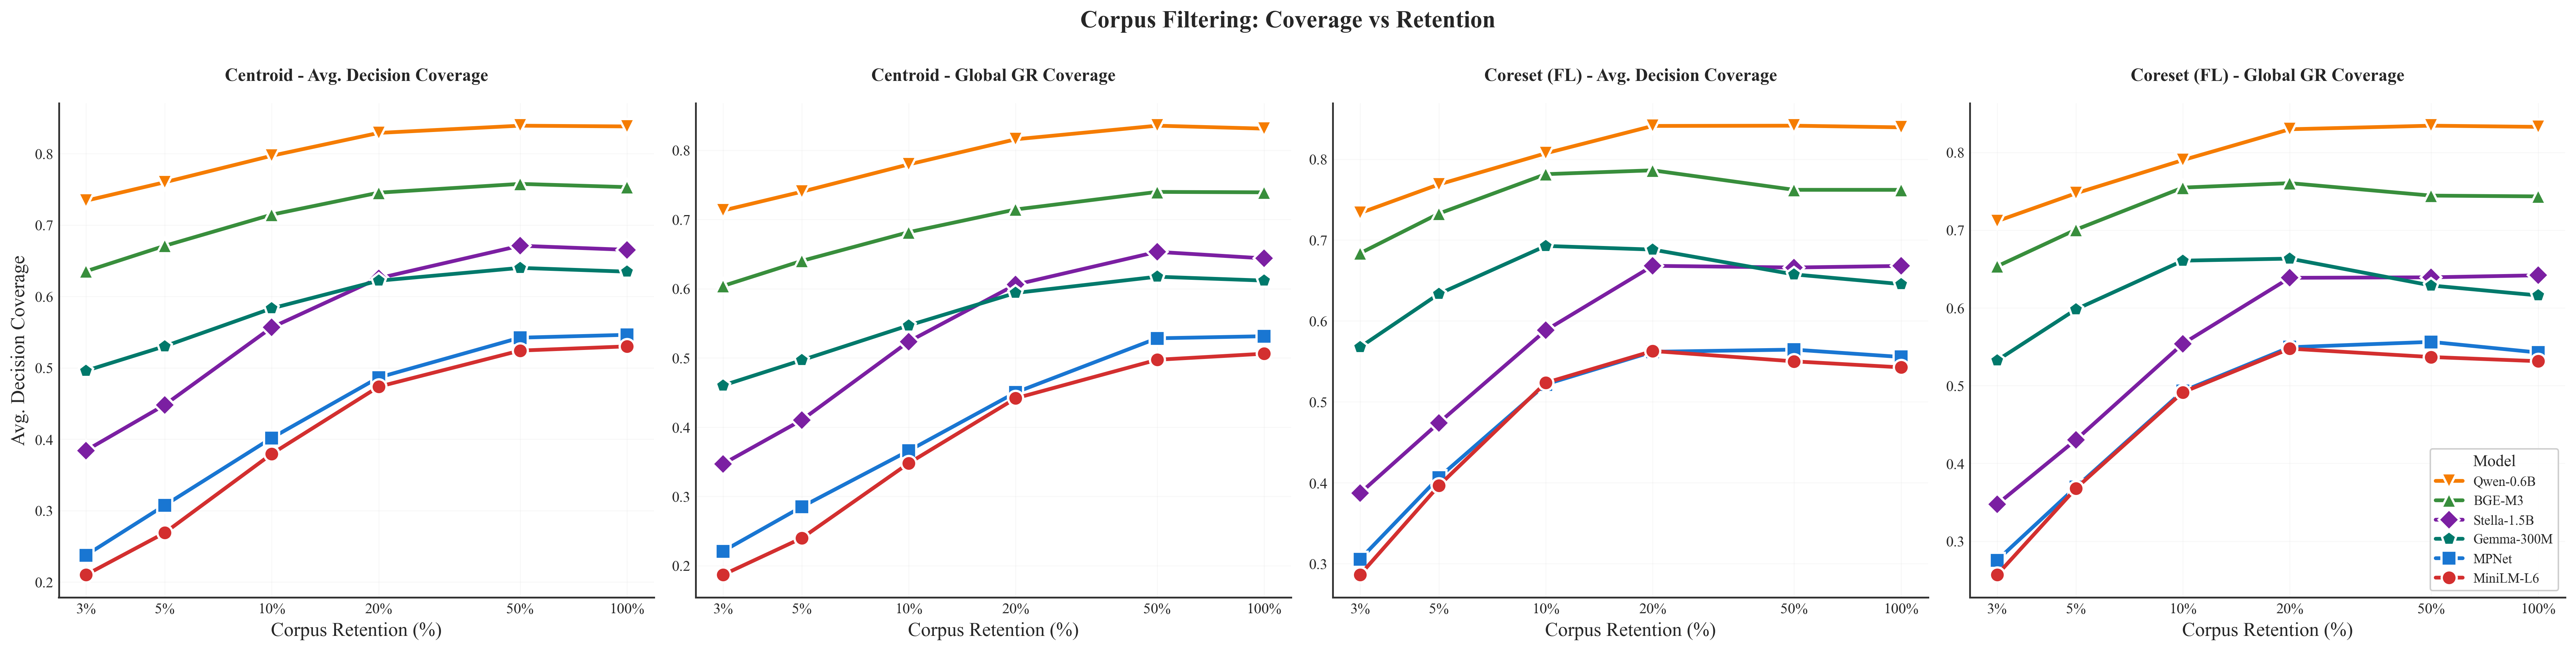


✓ Saved 1x4 filter coverage plot to figures_final


In [14]:
# ============================================================================
# PLOT F1: Coverage vs Corpus Retention — 1x4 Grid (All Side-by-Side)
# ============================================================================
def plot_filter_coverage_1x4(df_agg, figsize=(24, 6)):
    """1x4 grid: all 4 combinations side-by-side."""
    
    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=False)
    
    prior_methods = ['centroid', 'coreset']
    metrics = [
        ('avg_dec_coverage', 'Avg. Decision Coverage'),
        ('gr_coverage', 'Global GR Coverage')
    ]
    
    plot_idx = 0
    for prior in prior_methods:
        data = df_agg[df_agg['prior_method'] == prior]
        
        for metric, metric_label in metrics:
            ax = axes[plot_idx]
            
            # Filter out zero retention
            plot_data = data[data['retain_pct'] > 0]
            grouped = plot_data.groupby(['model_short', 'retain_pct'])[metric].mean().reset_index()
            
            # Sort models by oracle performance
            oracle_data = grouped[grouped['retain_pct'] == 1.0]
            if len(oracle_data) > 0:
                oracle_perf = oracle_data.set_index('model_short')[metric].sort_values(ascending=False)
            else:
                oracle_perf = grouped.groupby('model_short')[metric].max().sort_values(ascending=False)
            
            for model in oracle_perf.index:
                mdata = grouped[grouped['model_short'] == model].sort_values('retain_pct')
                if len(mdata) == 0:
                    continue
                
                color = MODEL_COLORS.get(model, '#333333')
                marker = MODEL_MARKERS.get(model, 'o')
                ax.plot(mdata['retain_pct'] * 100, mdata[metric], '-',
                        marker=marker, label=model, color=color,
                        linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)
            
            # Labels and title
            ax.set_xlabel('Corpus Retention (%)', fontweight='medium')
            if plot_idx == 0:
                ax.set_ylabel(metric_label, fontweight='medium')
            ax.set_title(f'{PRIOR_NAMES[prior]} - {metric_label}', pad=15, fontweight='bold', fontsize=12)
            
            # Log scale
            retention_values = sorted(plot_data['retain_pct'].unique() * 100)
            ax.set_xscale('log')
            ax.set_xticks(retention_values)
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
            ax.grid(True, alpha=0.3)
            
            # Legend only on last plot
            if plot_idx == 3:
                ax.legend(title='Model', loc='lower right', ncol=1, framealpha=0.95, fontsize=9)
            
            plot_idx += 1
    
    fig.suptitle('Corpus Filtering: Coverage vs Retention', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    return fig, axes

# Generate 1x4 plot
fig, axes = plot_filter_coverage_1x4(df_filter_agg)
plt.savefig(FIGURES_DIR / 'filter_coverage_1x4_all.pdf')
plt.show()

print(f"\n✓ Saved 1x4 filter coverage plot to {FIGURES_DIR}")

In [15]:
# ============================================================================
# Table: Coverage at Different Retention Levels
# ============================================================================
def generate_filter_coverage_table(df_agg):
    """Generate table showing coverage at different retention levels for all models and prior methods."""
    
    print("\n" + "="*140)
    print("CORPUS FILTERING: COVERAGE AT DIFFERENT RETENTION LEVELS")
    print("="*140 + "\n")
    
    retention_levels = sorted(df_agg['retain_pct'].unique())
    table_data = []
    
    for prior in ['centroid', 'coreset']:
        prior_data = df_agg[df_agg['prior_method'] == prior]
        
        for model in sorted(df_agg['model_short'].unique()):
            model_data = prior_data[prior_data['model_short'] == model]
            
            row = {
                'Prior': PRIOR_NAMES[prior],
                'Model': model,
            }
            
            for retention in retention_levels:
                ret_data = model_data[model_data['retain_pct'] == retention]
                if len(ret_data) > 0:
                    avg_dec = ret_data['avg_dec_coverage'].values[0]
                    gr_cov = ret_data['gr_coverage'].values[0]
                    row[f'{int(retention*100)}%'] = f"{avg_dec:.3f} / {gr_cov:.3f}"
                else:
                    row[f'{int(retention*100)}%'] = "N/A"
            
            table_data.append(row)
    
    table_df = pd.DataFrame(table_data)
    print(table_df.to_string(index=False))
    print("\nFormat: Avg Decision Coverage / Global GR Coverage")
    print("="*140 + "\n")
    
    return table_df

# Generate comprehensive table
filter_table = generate_filter_coverage_table(df_filter_agg)


CORPUS FILTERING: COVERAGE AT DIFFERENT RETENTION LEVELS

       Prior       Model            3%            5%           10%           20%           50%          100%
    Centroid      BGE-M3 0.635 / 0.604 0.671 / 0.640 0.715 / 0.682 0.745 / 0.715 0.758 / 0.740 0.753 / 0.739
    Centroid  Gemma-300M 0.496 / 0.460 0.530 / 0.497 0.583 / 0.547 0.622 / 0.594 0.640 / 0.617 0.635 / 0.612
    Centroid       MPNet 0.237 / 0.221 0.307 / 0.285 0.402 / 0.366 0.486 / 0.450 0.542 / 0.528 0.546 / 0.531
    Centroid   MiniLM-L6 0.210 / 0.187 0.269 / 0.240 0.379 / 0.348 0.474 / 0.442 0.524 / 0.497 0.530 / 0.506
    Centroid   Qwen-0.6B 0.734 / 0.713 0.760 / 0.740 0.797 / 0.780 0.829 / 0.816 0.839 / 0.836 0.838 / 0.831
    Centroid Stella-1.5B 0.384 / 0.347 0.448 / 0.410 0.557 / 0.524 0.625 / 0.606 0.671 / 0.653 0.665 / 0.644
Coreset (FL)      BGE-M3 0.684 / 0.653 0.733 / 0.701 0.781 / 0.755 0.786 / 0.760 0.762 / 0.744 0.762 / 0.743
Coreset (FL)  Gemma-300M 0.568 / 0.532 0.633 / 0.598 0.693 / 0.661 0.

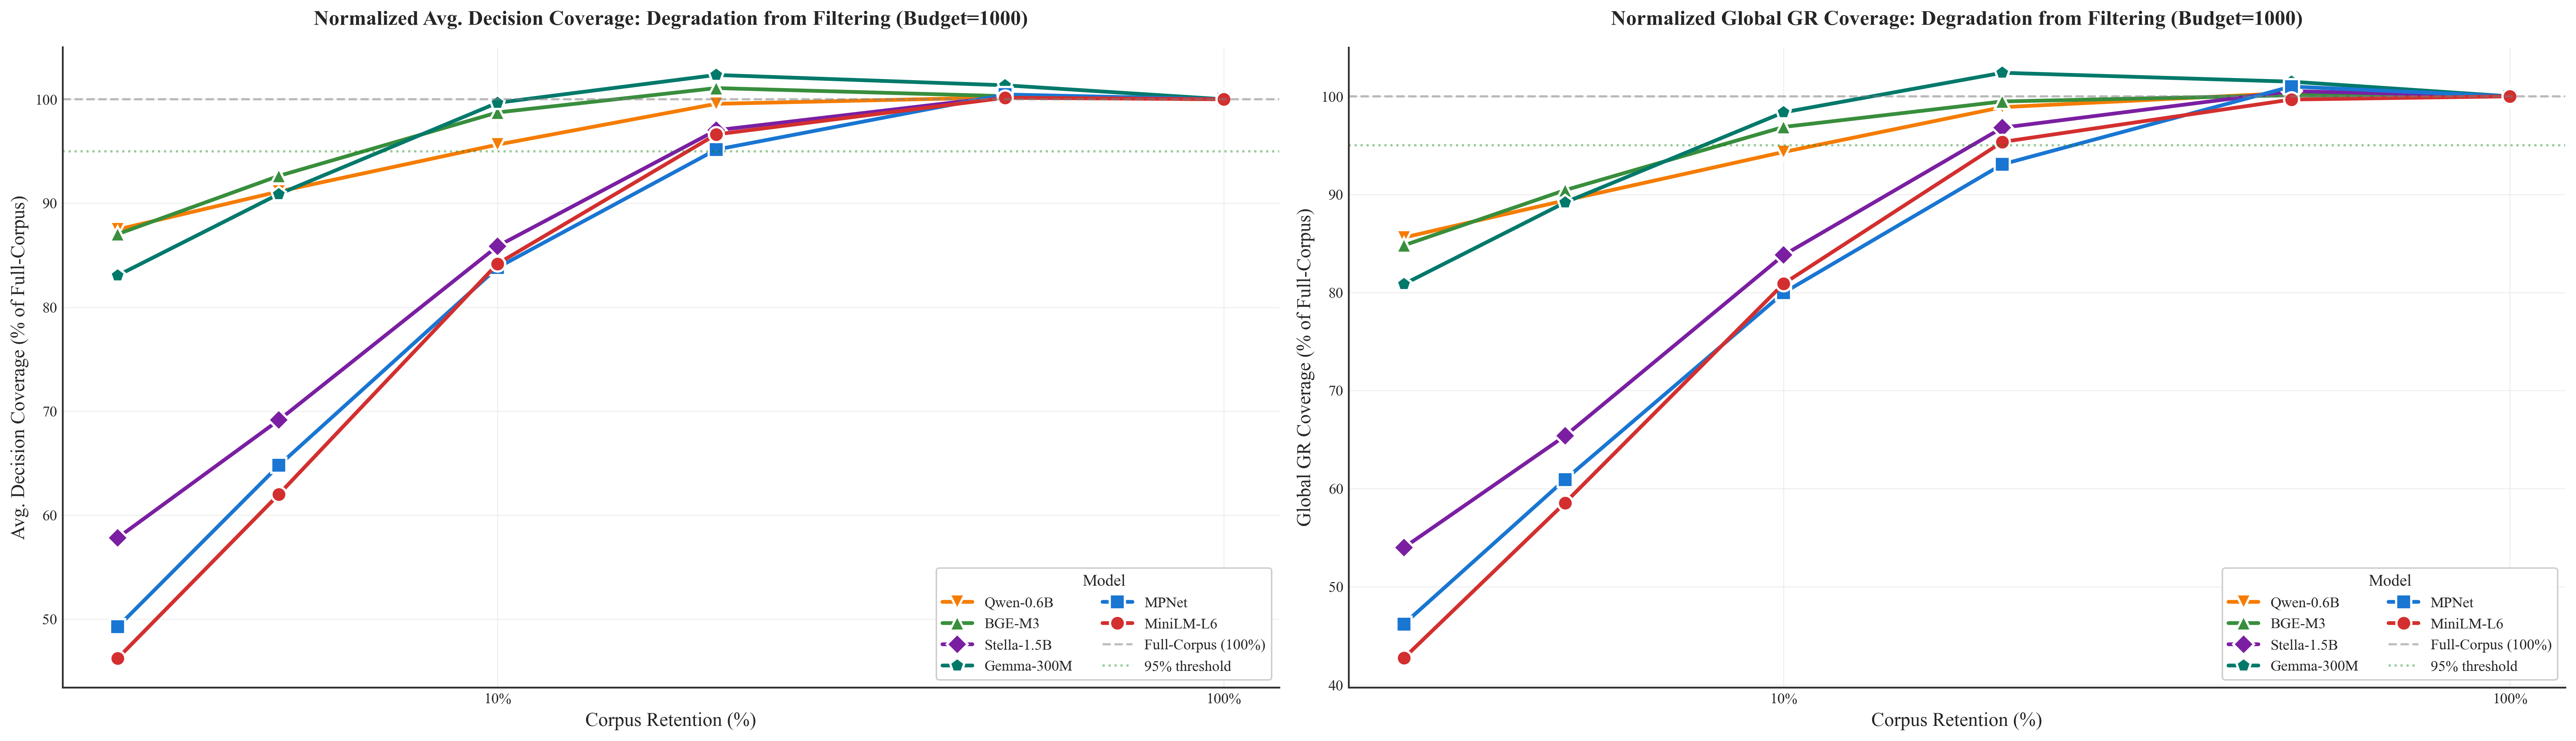

In [16]:
# ============================================================================
# PLOT F5: Normalized Coverage (% of full-corpus) — shows degradation relative to full corpus
# ============================================================================
def plot_filter_normalized_coverage(df_agg, metric, metric_label, ax=None):
    """Line plot: coverage normalized to oracle (100%) baseline, per model."""
    grouped = df_agg.groupby(['model_short', 'retain_pct'])[metric].mean().reset_index()
    
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 7))
    
    oracle_perf = grouped[grouped['retain_pct'] == 1.0].set_index('model_short')[metric]
    
    for model in oracle_perf.sort_values(ascending=False).index:
        mdata = grouped[grouped['model_short'] == model].sort_values('retain_pct').copy()
        oracle_val = oracle_perf[model]
        mdata['normalized'] = mdata[metric] / oracle_val * 100
        
        color = MODEL_COLORS.get(model, '#333333')
        marker = MODEL_MARKERS.get(model, 'o')
        ax.plot(mdata['retain_pct'] * 100, mdata['normalized'], '-',
                marker=marker, label=model, color=color,
                linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)
    
    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='Full-Corpus (100%)')
    ax.axhline(y=95, color='green', linestyle=':', alpha=0.4, linewidth=1.5, label='95% threshold')
    
    ax.set_xlabel('Corpus Retention (%)', fontweight='medium')
    ax.set_ylabel(f'{metric_label} (% of Full-Corpus)', fontweight='medium')
    ax.set_title(f'Normalized {metric_label}: Degradation from Filtering (Budget=1000)', pad=15)
    ax.legend(title='Model', loc='lower right', ncol=2, framealpha=0.95)
    ax.set_xticks([3, 5, 10, 20, 50, 100])
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_ylim(None, 105)
    
    return ax

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 7))
plot_filter_normalized_coverage(df_filter_agg, 'avg_dec_coverage', 'Avg. Decision Coverage', ax=ax1)
plot_filter_normalized_coverage(df_filter_agg, 'gr_coverage', 'Global GR Coverage', ax=ax2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'filter_normalized_combined.pdf')
plt.show()


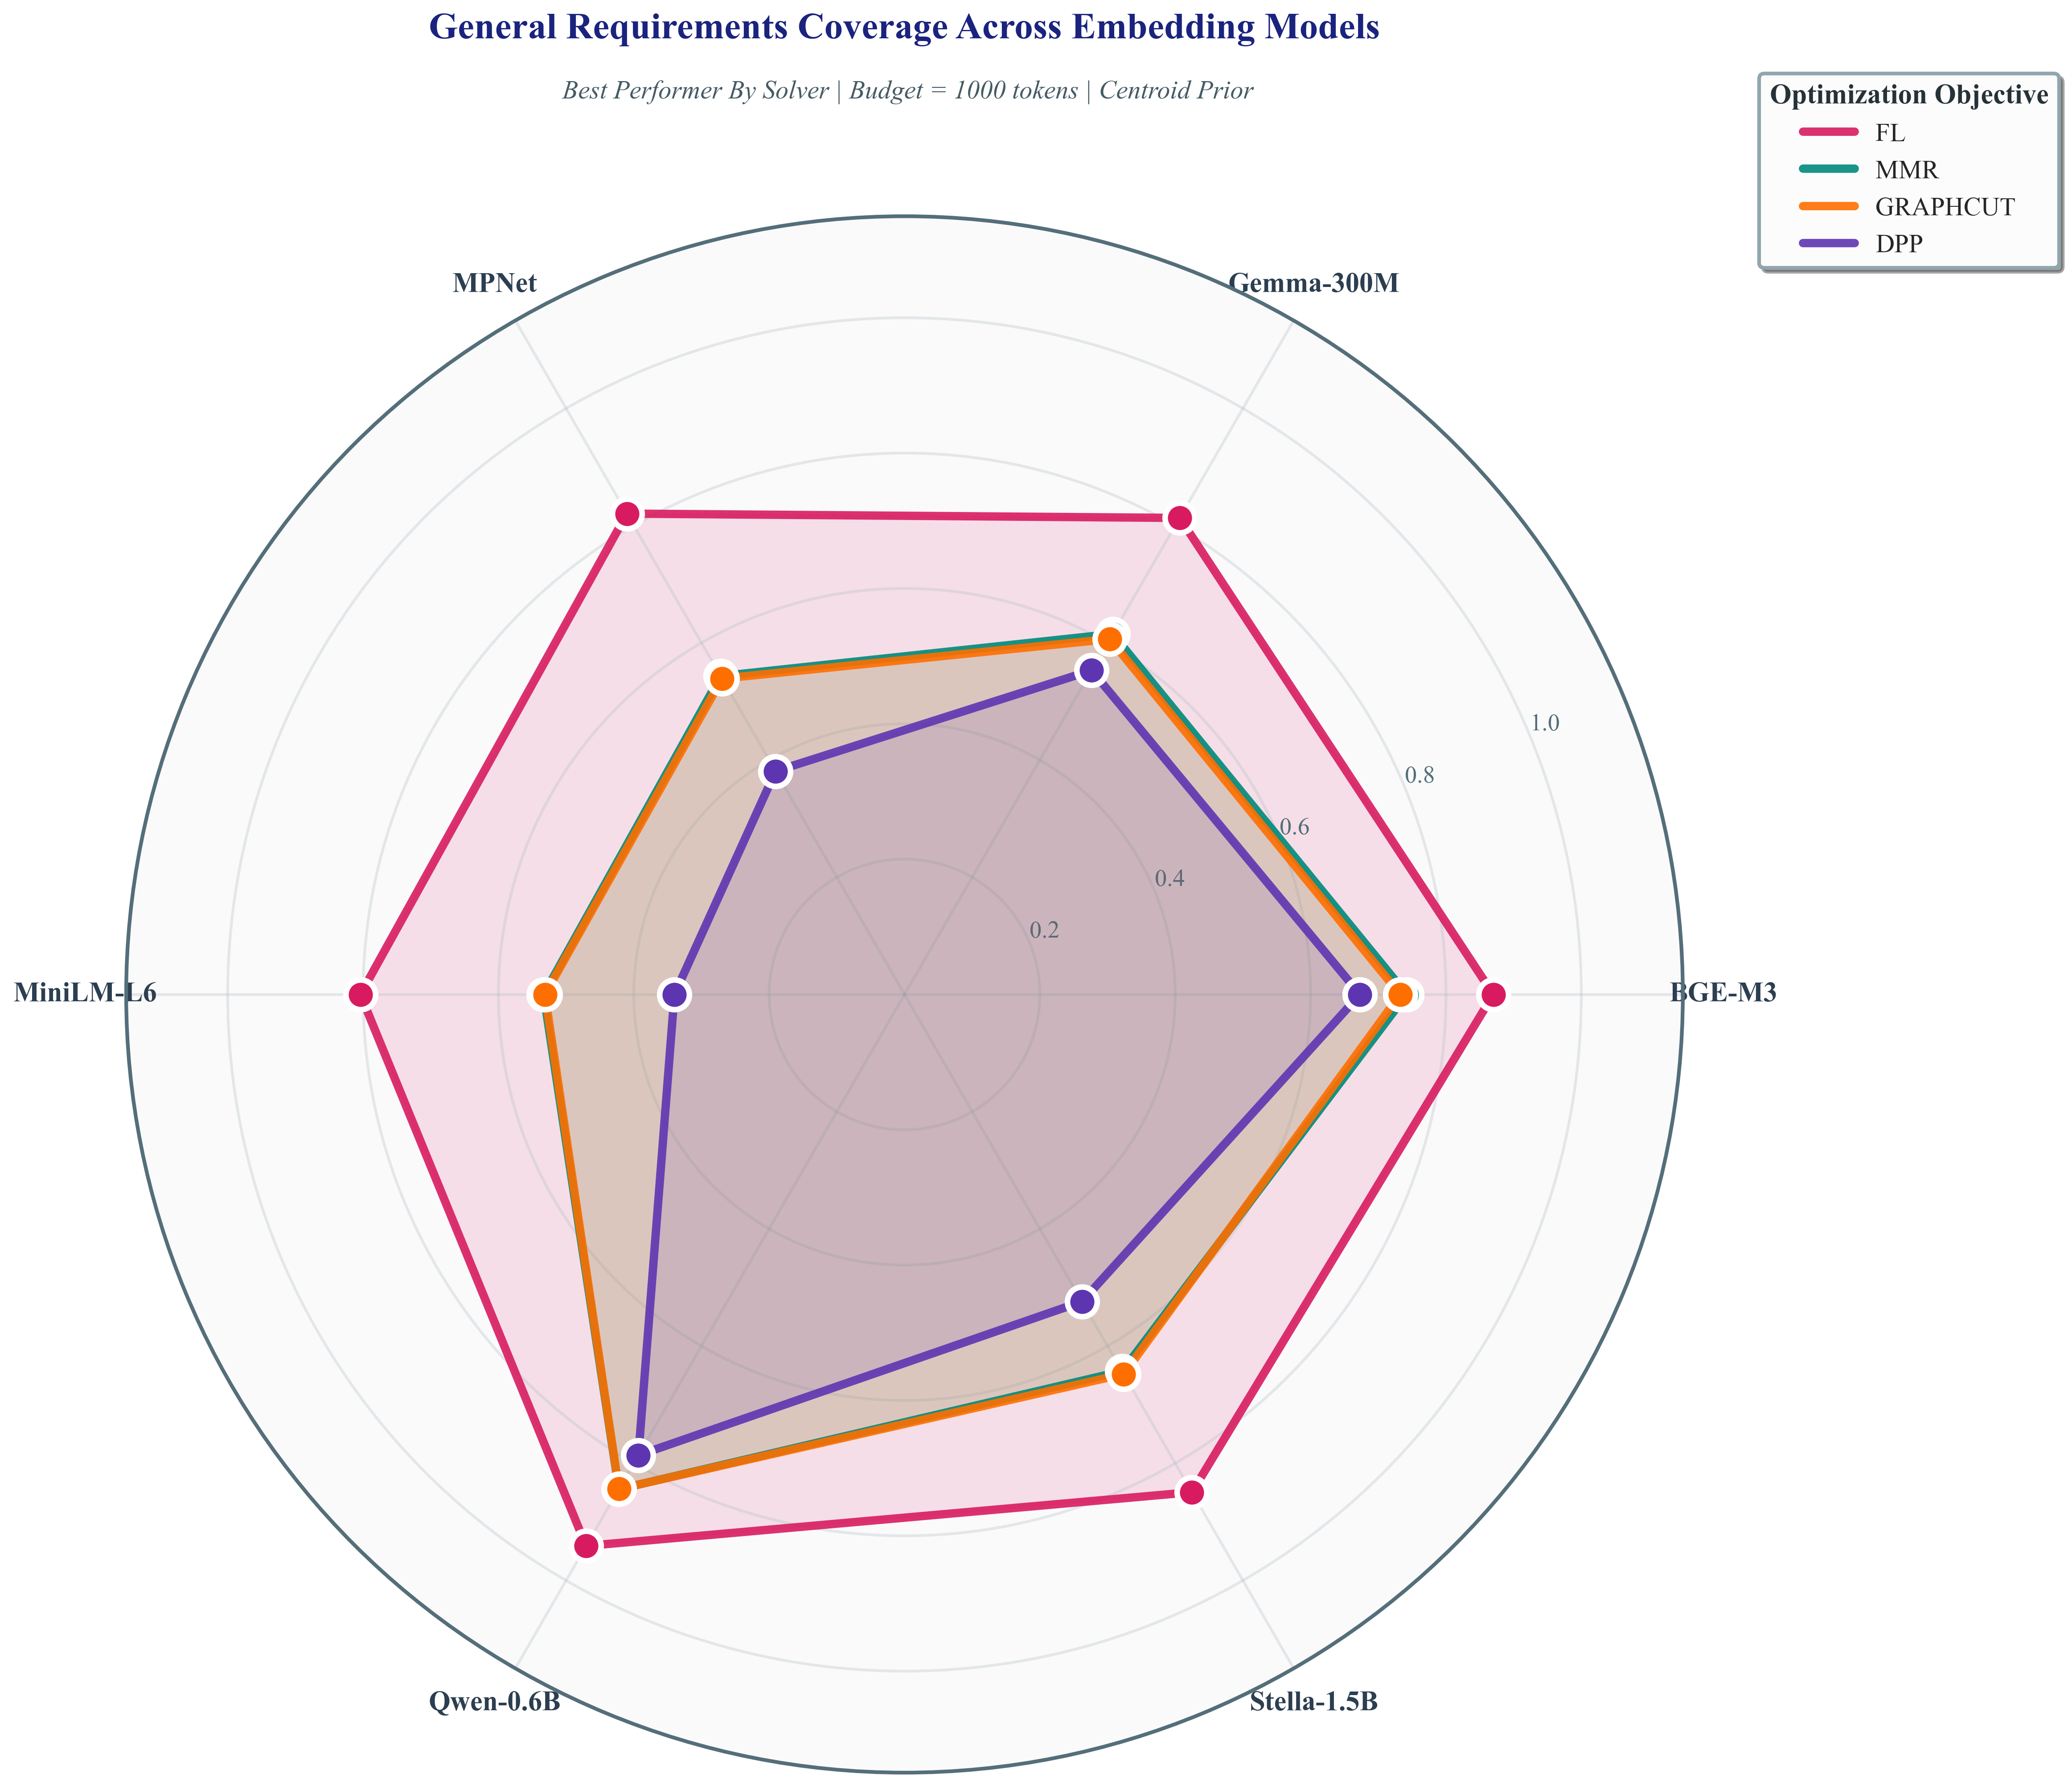


✓ Saved impressive spider plot to figures_final


In [17]:
# ============================================================================
# PLOT 9: Enhanced Spider Plot - Fixed Text Positioning
# ============================================================================
def plot_model_spider_impressive(df, metric, budget, prior_method=None, figsize=(16, 16)):
    """Highly impressive spider plot with enhanced styling and fixed text positioning."""
    
    data = df[df['budget'] == budget]
    if prior_method:
        data = data[data['prior_method'] == prior_method]
    
    fig = plt.figure(figsize=figsize, facecolor='white')
    ax = fig.add_subplot(111, projection='polar', facecolor='#FAFAFA')
    
    # Get models (axes)
    models = sorted(data['model_short'].unique())
    num_models = len(models)
    angles = np.linspace(0, 2 * np.pi, num_models, endpoint=False).tolist()
    angles += angles[:1]
    
    # Get objectives sorted by performance
    obj_perf = data.groupby('objective')[metric].max().sort_values(ascending=False)
    
    # Enhanced color scheme with better contrast
    enhanced_colors = {
        'fl': '#D81B60',      # Vibrant pink
        'mmr': '#00897B',     # Rich teal
        'graphcut': '#FF6F00', # Vibrant orange
        'dpp': '#5E35B1'      # Rich purple
    }
    
    # Plot each objective with enhanced styling
    for idx, obj in enumerate(obj_perf.index):
        obj_data = data[data['objective'] == obj]
        
        # Get best performance per model
        values = []
        for model in models:
            model_data = obj_data[obj_data['model_short'] == model]
            values.append(model_data[metric].max() if len(model_data) > 0 else 0)
        
        # Complete the circle
        values += values[:1]
        
        # Plot with enhanced styling
        color = enhanced_colors.get(obj, OBJECTIVE_COLORS.get(obj, '#333333'))
        
        # Main line with glow effect
        ax.plot(angles, values, '-', linewidth=4.5, 
               label=obj.upper(), color=color, 
               alpha=0.9, zorder=10+idx)
        
        # Add markers
        ax.plot(angles, values, 'o', 
               markersize=16, color=color,
               markeredgecolor='white', markeredgewidth=3,
               zorder=20+idx)
        
        # Filled area with gradient effect
        ax.fill(angles, values, alpha=0.12, color=color, zorder=idx)
    
    # Enhanced grid styling
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(models, fontsize=15, fontweight='bold', color='#2C3E50')
    
    # Y-axis with better spacing - extended to give room for labels
    ax.set_ylim(0, 1.15)  # Extended from 1.0 to 1.15
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], 
                       fontsize=13, color='#546E7A', fontweight='medium')
    
    # Adjust radial label position to prevent overflow
    ax.tick_params(pad=15)  # Increased padding
    
    # Enhanced grid
    ax.grid(True, alpha=0.3, linewidth=1.5, color='#B0BEC5', linestyle='-')
    ax.spines['polar'].set_color('#546E7A')
    ax.spines['polar'].set_linewidth(2)
    
    # Title with better formatting
    # title = f'{METRIC_NAMES.get(metric, metric)} Across Embedding Models'
    title = "General Requirements Coverage Across Embedding Models"
    subtitle = f' Best Performer By Solver | Budget = {budget} tokens'
    if prior_method:
        subtitle += f' | {PRIOR_NAMES[prior_method]} Prior'
    
    ax.text(0.5, 1.12, title, 
           transform=ax.transAxes,
           ha='center', va='center',
           fontsize=20, fontweight='bold', color='#1A237E')
    ax.text(0.5, 1.08, subtitle,
           transform=ax.transAxes, 
           ha='center', va='center',
           fontsize=14, color='#455A64', style='italic')
    
    # Enhanced legend with custom styling
    legend = ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10), 
                      fontsize=14, framealpha=0.98, frameon=True,
                      title='Optimization Objective', title_fontsize=15,
                      edgecolor='#90A4AE', fancybox=True, shadow=True)
    legend.get_frame().set_linewidth(2)
    legend.get_title().set_fontweight('bold')
    legend.get_title().set_color('#263238')
    
    plt.tight_layout(pad=2.0)  # Added padding
    return fig, ax

# Generate impressive spider plot
fig, ax = plot_model_spider_impressive(df, 'global_gr_coverage', budget=1000, prior_method='centroid')
plt.savefig(FIGURES_DIR / f'model_spider_impressive_globalgr_centroid_B1000.pdf', 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'model_spider_impressive_globalgr_centroid_B1000.png', 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Saved impressive spider plot to {FIGURES_DIR}")

In [18]:
a = [1,2, [3,4]]

In [19]:
b = list(a)
b[2][1] = 3

In [20]:
a

[1, 2, [3, 3]]

In [21]:
from copy import deepcopy
c = deepcopy(a)
c[2][0] = 0

In [22]:
c, a

([1, 2, [0, 3]], [1, 2, [3, 3]])

In [23]:
a = np.array([[1,2,3], [4,5,6]])
b = a.copy()
b[0,0] = 0

In [24]:
print(a)

[[1 2 3]
 [4 5 6]]


In [25]:
print(b)

[[0 2 3]
 [4 5 6]]
